## NMD Models: Survival Decay Model

This notebook shows how to develop the survival decay analysis modeling for Non-Maturity Deposits.

| Step | Description |
|---|---|
| 1 | Track balances month-over-month per cohort |
| 2 | Compute runoff rate per cohort |
| 3 | Average runoff rate per snapshot convert into discrete hazard rate |
| 4a | Worst-case percentile |
| 4b | OLS regression with MEV(s) (repo rate, unemployment) |

In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [29]:
# Import libraries
import warnings
import pandas as pd
import pickle
import sys; sys.path.insert(0, "..")

from src.survival_analysis import (
    simulate_cohorts, compute_cohort_runoff_rates, compute_snapshot_hazard_rates,
    worst_case_runoff, regress_runoff_on_mev
)
from src.plot_function import plot_survival_results

pd.options.display.float_format = "{:.3f}".format
warnings.simplefilter(action = "ignore", category = pd.errors.PerformanceWarning)

In [3]:
# Load Data
df = pd.read_parquet(
    '../data/raw/nmd_data.parquet',
    engine = "pyarrow"
)

# Show table
df.head(5)

,balance,deposit_rate,market_rate,repo_rate,unemployment,cds_spread,wealth,equity_return,equity_vol
date,,,,,,,,,
2012-01-31,5000.000,0.011,0.055,0.025,0.045,55.000,1000.000,-0.000,0.180
2012-02-29,4988.099,0.011,0.048,0.021,0.043,53.617,1030.391,0.056,0.167
2012-03-31,4992.052,0.011,0.047,0.024,0.046,48.113,1020.081,-0.011,0.169
2012-04-30,4948.485,0.012,0.049,0.026,0.044,63.174,1046.073,0.045,0.156
2012-05-31,5054.238,0.010,0.043,0.022,0.042,77.784,1039.899,-0.018,0.124


In [4]:
# Simulate cohorts
cohort_matrix = simulate_cohorts(
    balance = df["balance"],
    n_cohorts = 30,
    seed = 42
)

print(f"Cohort matrix shape: {cohort_matrix.shape}")

# Show sample simulated cohort
cohort_matrix.iloc[:6, :5]

Cohort matrix shape: (150, 30)


date,2012-01-31,2012-06-30,2012-11-30,2013-04-30,2013-09-30
date,,,,,
2012-01-31,166.093,NaN,NaN,NaN,NaN
2012-02-29,159.233,NaN,NaN,NaN,NaN
2012-03-31,152.504,NaN,NaN,NaN,NaN
2012-04-30,148.264,NaN,NaN,NaN,NaN
2012-05-31,143.661,NaN,NaN,NaN,NaN
2012-06-30,138.174,137.797,NaN,NaN,NaN


In [5]:
# Compute runoff rates
runoff_rates = compute_cohort_runoff_rates(cohort_matrix)
print(f"Runoff rate matrix shape : {runoff_rates.shape}")

# Show runoff rates (Same cohort)
runoff_rates.iloc[:7, :5]

Runoff rate matrix shape : (150, 30)


date,2012-01-31,2012-06-30,2012-11-30,2013-04-30,2013-09-30
date,,,,,
2012-01-31,NaN,NaN,NaN,NaN,NaN
2012-02-29,0.041,NaN,NaN,NaN,NaN
2012-03-31,0.042,NaN,NaN,NaN,NaN
2012-04-30,0.028,NaN,NaN,NaN,NaN
2012-05-31,0.031,NaN,NaN,NaN,NaN
2012-06-30,0.038,NaN,NaN,NaN,NaN
2012-07-31,0.036,0.022,NaN,NaN,NaN


In [30]:
# Snapshot hazard rates
hazard_rates = compute_snapshot_hazard_rates(runoff_rates)

# Result
print("=" * 60)
print(f"{"Hazard rate series length":<{30}}: {len(hazard_rates)}")
print(f"{"Average hazard rate":<{30}}: {hazard_rates.mean():.2%}")
print(f"{"Max hazard rate":<{30}}: {hazard_rates.max():.2%}")
print("=" * 60)

# Export (For use in build runoff profile)
with open("../model/hazard_rate.pkl", "wb") as file:
    pickle.dump(hazard_rates, file)

Hazard rate series length     : 150
Average hazard rate           : 3.65%
Max hazard rate               : 4.56%


In [17]:
# Worst case percentile
worst_case = worst_case_runoff(
    hazard_rates = hazard_rates,
    percentile = 95.0
)

# Result
print("=" * 60)
print(f"{"Worst-case runoff rate (P95)":<{30}}: {worst_case["worst_case_rate"]:.2%}")
print(f"{"Mean runoff rate":<{30}}: {worst_case["mean_rate"]:.2%}")
print(f"{"Std runoff rate":<{30}}: {worst_case["std_rate"]:.2%}")
print("=" * 60)

Worst-case runoff rate (P95)  : 4.16%
Mean runoff rate              : 3.65%
Std runoff rate               : 0.27%


In [18]:
# MEV Regression
MEV_COLS = ["repo_rate", "unemployment"]

reg_result = regress_runoff_on_mev(
    hazard_rates = hazard_rates,
    mev_df = df,
    mev_cols = MEV_COLS
)

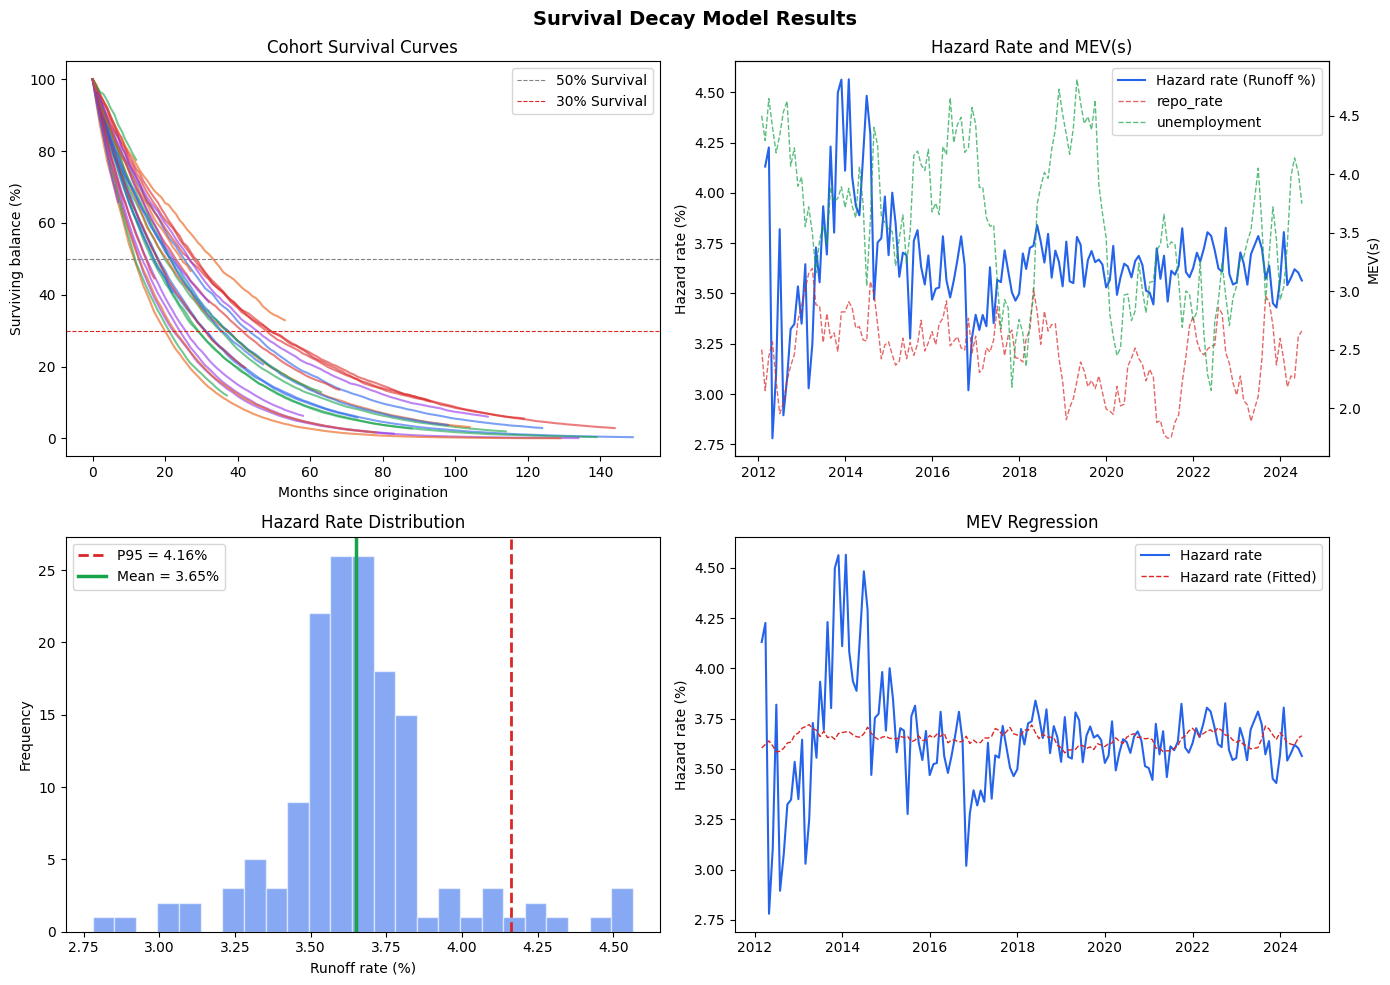

In [19]:
# Plot visualise results
plot_survival_results(
    cohort_matrix = cohort_matrix,
    hazard_rates = hazard_rates,
    worst_case = worst_case,
    reg_result = reg_result,
    mev_df = df,
    mev_cols = MEV_COLS,
    n_cohorts_to_plot = 30
)

In [27]:
# Stressed runoff rate by MEV Scenario
# Using regression coefficients for project runoff rate in a given macro stress scenario
coef = reg_result['coefficients']

base_repo = df['repo_rate'].mean()
base_unemp = df['unemployment'].mean()

stress_repo = base_repo + 0.015    #+150 bps
stress_unemp = base_unemp + 0.020  #+2 pp

base_rate = (
    coef['intercept']
    + coef['repo_rate'] * base_repo
    + coef['unemployment'] * base_unemp
)

stressed_rate = (
    coef['intercept']
    + coef['repo_rate'] * stress_repo
    + coef['unemployment'] * stress_unemp
)

# Result
print("=" * 60)
print("Stressed runoff rate by MEV Scenario")
print(f"{"Base runoff rate":<{25}}: {base_rate:.2%}")
print(f"{"Stressed runoff rate":{25}}: {stressed_rate:.2%}")
print(f"{"Incremental stress":<{25}}: {(stressed_rate - base_rate):.2%}")
print("=" * 60)

Stressed runoff rate by MEV Scenario
Base runoff rate         : 3.65%
Stressed runoff rate     : 3.74%
Incremental stress       : 0.09%
